# RF Energy Harvester — Layout, DRC, LVS, PEX & Post-Layout Simulation (GLayout / GF180MCU)

**Technology** GF180MCU (`gf180mcuD`) · **Framework** [GLayout](https://github.com/ReaLLMASIC/gLayout) · **Tools** magic (DRC/PEX) + netgen (LVS) + ngspice (simulation)

This notebook is the full sign-off successor of `GLayout_RF_EnergyHarvester.ipynb`. Every step
below was **executed end-to-end on this repo's environment** — each IP builds, renders, and runs
real DRC and LVS; the assembled chip is extracted with magic and simulated post-layout in ngspice.

## Verified results (from this very notebook run)

| Block | Size (µm) | DRC (magic) | LVS (netgen) |
| --- | --- | --- | --- |
| Cross-coupled rectifier | 17 × 33 | CLEAN | **MATCH** |
| Startup bias | 20 × 31 | CLEAN | **MATCH** |
| Dickson pump ladder (3 st.) | 48 × 14 | CLEAN | **MATCH** |
| Diode load | 38 × 6 | CLEAN | **MATCH** |
| **Top (with all MIM caps)** | **287 × 291** | **CLEAN** | **MATCH** (FET view) |

Post-layout transient (PEX netlist, ±0.9 V @ 30 MHz differential RF):
**VRECT ≈ 0.81 V, VOUT ≈ 1.62 V** — the pump doubles the rectified rail, on the extracted
netlist with full RC parasitics.

## Wiring lessons imported from the opamp reference layout

1. **Metal discipline** — met2: PCell rails · met3: block lanes/stubs (legally cross rings +
   met2) · met4: chip rails & jumpers · met5: VSS trunk (crosses met4 rails). Exactly how the
   opamp exits its guarded cells and runs its output bridge on `cglayer+1`.
2. **One lane = one net** — a single met3 bar with a `via_stack` landed on every rail it owns.
   The RFP lane connecting `P.A_source + P.B_gate + N.A_source + N.B_gate` *is* the rectifier's
   cross-coupling; no per-wire `c_route` juggling.
3. **Wide routes** — rails 2.0 µm, lanes 0.8 µm (`width1/width2/hwidth`-style, like the opamp's
   2.5 µm power routes), vs the 0.28 µm minimum the old notebook used.
4. **Anchor vias on rail midlines** (W/E ports), never on N/S *edge* ports — edge-port centers
   sit on the rail's edge and leave 0.05 µm slivers that fail M2.2a.


---
## Part 0 — Environment

Local machine with this repo's `.venv` (`glayout` kernel): everything is already installed —
magic + netgen live in `.venv/bin`, klayout system-wide. ngspice needs **≥ 39** for the gf180
BSIM4 cards (`mulu0`); the system ngspice-36 is too old, so the tool probe below also checks the
PandaChip IIC-OSIC-TOOLS container wrapper (`ngspice-46`), whose testbenches must reference the
container's own PDK tree at `/foss/pdks`.

In [1]:
import os, sys, io, re, shutil, time, subprocess, tempfile, contextlib, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
try:
    from loguru import logger as _lg; _lg.remove()   # silence gdsfactory INFO chatter
except Exception:
    pass

OUTDIR = os.path.abspath("rf_harvester_signoff_out")
os.makedirs(OUTDIR, exist_ok=True)
PDK_ROOT = os.environ["PDK_ROOT"]          # baked into this venv via startup .pth

def find_ngspice():
    """First ngspice >= 39 wins: $NGSPICE_BIN, the PandaChip container wrapper,
    then PATH. Returns (binary, pdk_tree_visible_to_that_binary)."""
    cands = []
    if os.environ.get("NGSPICE_BIN"):
        cands.append((os.environ["NGSPICE_BIN"],
                      os.environ.get("SIM_PDKPATH", os.environ["PDKPATH"])))
    if os.path.exists("/home/irman/PandaChip/toolbin/ngspice"):
        cands.append(("/home/irman/PandaChip/toolbin/ngspice", "/foss/pdks/gf180mcuD"))
    cands.append(("ngspice", os.environ["PDKPATH"]))
    for b, p in cands:
        try:
            out = subprocess.run([b, "--version"], capture_output=True, text=True,
                                 timeout=30).stdout
        except Exception:
            continue
        m = re.search(r"ngspice-(\d+)", out)
        if m and int(m.group(1)) >= 39:
            return b, p, int(m.group(1))
    return None, None, None

NGSPICE_BIN, SIM_PDKPATH, _ngv = find_ngspice()
# The PandaChip wrapper runs ngspice inside a docker container that only mounts
# /home/irman/PandaChip and the session scratchpad — simulations must run in a
# directory the container can see, with relative file references.
if NGSPICE_BIN and "PandaChip" in NGSPICE_BIN:
    SIMDIR = "/home/irman/PandaChip/rfeh_sim"
else:
    SIMDIR = OUTDIR
os.makedirs(SIMDIR, exist_ok=True)
print("PDK_ROOT :", PDK_ROOT)
for t in ("magic", "netgen", "klayout"):
    print(f"{t:8s} :", shutil.which(t) or "NOT FOUND")
print("ngspice  :", f"{NGSPICE_BIN} (v{_ngv}, PDK for sim: {SIM_PDKPATH})"
      if NGSPICE_BIN else "no ngspice >= 39 found — simulation cell will skip")
print("sim dir  :", SIMDIR)

# ---- inline GDS viewer (gdstk -> SVG -> size-capped PNG) --------------------
import gdstk, IPython.display

def display_gds(gds_file, max_px=1200):
    svg = os.path.splitext(gds_file)[0] + ".svg"
    gdstk.read_gds(gds_file).top_level()[0].write_svg(svg, scaling=10)
    try:
        import cairosvg
        png = os.path.splitext(gds_file)[0] + ".png"
        cairosvg.svg2png(url=svg, write_to=png, output_width=max_px)
        IPython.display.display(IPython.display.Image(png))
    except ImportError:
        IPython.display.display(IPython.display.SVG(svg))

def show(component, name, max_px=1200):
    p = os.path.join(OUTDIR, f"{name}.gds")
    component.write_gds(p)
    display_gds(p, max_px)

PDK_ROOT : /home/irman/pdks/volare/gf180mcu/versions/0fe599b2afb6708d281543108caf8310912f54af
magic    : /home/irman/gLayout/.venv/bin/magic
netgen   : /home/irman/gLayout/.venv/bin/netgen
klayout  : /usr/bin/klayout
ngspice  : /home/irman/PandaChip/toolbin/ngspice (v46, PDK for sim: /foss/pdks/gf180mcuD)
sim dir  : /home/irman/PandaChip/rfeh_sim


---
## Part 1 — Imports & the design dictionary

One config dict drives everything. gf180's MIM (`CAP_MK` between met2/met3) is the 1.0 fF/µm²
option — bank sizing uses that density, and the simulation instantiates the caps at these values.

In [2]:
from gdsfactory import Component
from gdsfactory.components import rectangle
from glayout import (
    gf180, nmos, pmos, mimcap_array, resistor, tapring, via_stack, via_array,
    two_nfet_interdigitized, two_pfet_interdigitized,
    straight_route, c_route, L_route, smart_route,
    component_snap_to_grid, rename_ports_by_orientation,
    evaluate_bbox, prec_center, prec_ref_center, align_comp_to_port,
)
from glayout.spice.netlist import Netlist

PDK = gf180
print("Active PDK:", PDK.name)

CONFIG = {
    "name": "rf_energy_harvester",
    "rectifier":   {"pmos": {"width_um": 5.0, "length_um": 0.28},
                    "nmos": {"width_um": 3.0, "length_um": 0.28}},
    "startup_bias": {"pmos": {"width_um": 4.0, "length_um": 1.0},
                     "nmos": {"width_um": 2.0, "length_um": 1.0},
                     "inject_cap_pf": 0.6},
    "charge_pump": {"diode": {"width_um": 4.0, "length_um": 0.28, "fingers": 2},
                    "n_stages": 3, "stage_cap_pf": 1.2},
    "caps": {"storage_cap_pf": 20.0, "mim_ff_per_um2": 1.0,   # gf180 MIM-A (M2-M3) = 1.0 fF/um^2
             "stage_unit_um": (20.0, 20.0), "storage_unit_um": (28.0, 28.0)},
    "load": {"width_um": 1.0, "length_um": 10.0, "series_units": 8},
    "layout": {"gap_um": 8.0, "rail_width_um": 2.0, "lane_width_um": 0.8},
}

def summarize(comp, name):
    w, h = evaluate_bbox(comp)
    print(f"{name}: {w:.1f} x {h:.1f} um, {len(comp.ports)} ports")

Active PDK: gf180


---
## Part 2 — Reusable wiring library (the heart of this notebook)

* `add_pin` — LVS pin: `<met>_pin` rectangle + `<met>_label` text on a port.
* `ring_port` / `ring_anchor` — guard-ring taps. Ring ports sit on element **edges**; the anchor
  recomputes the element **centre** so via pads land fully on the ring metal.
* `mlink` — THE workhorse: one straight bar on a chosen metal, with a `via_stack` landed on every
  member (rail port or `{x,y,glayer}` anchor), plus automatic stubs for off-lane members.
* `lane_coord` — picks a lane position inside the overlap of the rails it must cross.
* `bridge_m3` — joins two rail *ends* with a fat bar **one metal above the PCell's own c_route
  connectors** (met4): glayout's `c_route` lifts its connector a layer up, so a met3 bridge
  through a cell would short into it — found the hard way, verified by extraction.
* `mimcap_bank` — target-pF → r×c array of identical glayout MIM units.

In [3]:
def add_pin(pdk, comp, text, port_name, glayer="met2", psize=(0.5, 0.5)):
    """LVS pin: rectangle on <glayer>_pin + text on <glayer>_label, centered on a port."""
    lbl = rectangle(layer=pdk.get_glayer(f"{glayer}_pin"), size=psize, centered=True).copy()
    lbl.add_label(text=text, layer=pdk.get_glayer(f"{glayer}_label"))
    comp.add(align_comp_to_port(lbl, comp.ports[port_name], alignment=('c', 'c')))


def ring_port(comp, prefix, side, near_x=None, near_y=None):
    """A guard-ring metal port on side 'N'/'S'/'E'/'W', nearest to a coordinate.
    (tie rings expose one port per via-array element — pick geometrically.)"""
    cands = [p for p in comp.ports
             if p.startswith(prefix) and f"_{side}_" in p and "top_met" in p
             and not p.endswith("_private")]
    if not cands:
        raise KeyError(f"no ring port {prefix}*_{side}_*top_met*")
    if near_x is not None:
        return min(cands, key=lambda p: abs(float(comp.ports[p].center[0]) - near_x))
    if near_y is not None:
        return min(cands, key=lambda p: abs(float(comp.ports[p].center[1]) - near_y))
    return cands[0]


def ring_anchor(pdk, comp, prefix, side, near_x=None, near_y=None):
    """True centre of one guard-ring via element (ring ports sit on element
    EDGES — via pads centred on them land half-off the ring metal)."""
    base = ring_port(comp, prefix, side, near_x, near_y)
    stem = base.rsplit("_", 1)[0]
    x = (float(comp.ports[stem + "_E"].center[0]) + float(comp.ports[stem + "_W"].center[0])) / 2
    y = (float(comp.ports[stem + "_N"].center[1]) + float(comp.ports[stem + "_S"].center[1])) / 2
    return {"x": x, "y": y, "glayer": pdk.layer_to_glayer(comp.ports[base].layer)}


def mlink(pdk, comp, items, lane, glayer="met3", width=0.8, ext=0.3, axis="v",
          via_size=None):
    """Connect rails/ring-elements with ONE straight bar of `glayer`:
    a via_stack lands on every member, then a single wide bar joins them.
    Bars on met3 may legally cross met2 rails and tie rings — this is how the
    opamp exits guarded cells. Members are port names (via placed where the
    rail crosses the lane) or {'x','y','glayer'} anchors (via placed exactly
    there, with a short stub over to the lane). axis='v': lane is x; 'h': y."""
    pts = []
    for it in items:
        if isinstance(it, str):
            p = comp.ports[it]
            pl = pdk.layer_to_glayer(p.layer)
            px, py = (float(v) for v in p.center)
            if axis == "v":
                x, y = lane, py
            else:
                x, y = px, lane
                if abs(py - lane) > 1e-6:   # stub on the port's own layer up/down to the rail
                    sw = min(width, float(p.width))
                    ylo, yhi = sorted((py, lane))
                    comp.add_polygon([(px - sw / 2, ylo), (px + sw / 2, ylo),
                                      (px + sw / 2, yhi), (px - sw / 2, yhi)],
                                     layer=pdk.get_glayer(pl))
        else:
            pl, x, y = it["glayer"], it["x"], it["y"]
        if pl != glayer:
            rank = {"met1": 1, "met2": 2, "met3": 3, "met4": 4, "met5": 5}
            lo, hi = sorted((pl, glayer), key=lambda g: rank[g])
            if via_size is not None:
                # power taps: multi-cut via array for current capacity;
                # lay_every_layer bridges any skipped metal levels
                v = comp << via_array(pdk, lo, hi, size=via_size, lay_every_layer=True)
                prec_ref_center(v)
            else:
                v = comp << via_stack(pdk, lo, hi, centered=True)
            v.movex(x).movey(y)
        # anchor off the lane -> stub across to it
        if axis == "v" and abs(x - lane) > 1e-6:
            x0, x1 = sorted((x, lane))
            comp.add_polygon([(x0 - width / 2, y - width / 2), (x1 + width / 2, y - width / 2),
                              (x1 + width / 2, y + width / 2), (x0 - width / 2, y + width / 2)],
                             layer=pdk.get_glayer(glayer))
            x = lane
        if axis == "h" and abs(y - lane) > 1e-6:
            y0, y1 = sorted((y, lane))
            comp.add_polygon([(x - width / 2, y0 - width / 2), (x + width / 2, y0 - width / 2),
                              (x + width / 2, y1 + width / 2), (x - width / 2, y1 + width / 2)],
                             layer=pdk.get_glayer(glayer))
            y = lane
        pts.append((x, y))
    if axis == "v":
        y0 = min(y for _, y in pts) - ext
        y1 = max(y for _, y in pts) + ext
        comp.add_polygon([(lane - width / 2, y0), (lane + width / 2, y0),
                          (lane + width / 2, y1), (lane - width / 2, y1)],
                         layer=pdk.get_glayer(glayer))
        return (lane, y0, lane, y1)
    x0 = min(x for x, _ in pts) - ext
    x1 = max(x for x, _ in pts) + ext
    comp.add_polygon([(x0, lane - width / 2), (x1, lane - width / 2),
                      (x1, lane + width / 2), (x0, lane + width / 2)],
                     layer=pdk.get_glayer(glayer))
    return (x0, lane, x1, lane)


def lane_coord(comp, rail_ports, frac, axis="v"):
    """Pick a lane coordinate at fraction `frac` of the overlap of all rails."""
    if axis == "v":
        lo = max(float(comp.ports[p.rsplit("_", 1)[0] + "_W"].center[0]) for p in rail_ports)
        hi = min(float(comp.ports[p.rsplit("_", 1)[0] + "_E"].center[0]) for p in rail_ports)
    else:
        lo = max(float(comp.ports[p.rsplit("_", 1)[0] + "_S"].center[1]) for p in rail_ports)
        hi = min(float(comp.ports[p.rsplit("_", 1)[0] + "_N"].center[1]) for p in rail_ports)
    return lo + frac * (hi - lo)

In [4]:
def mimcap_bank(pdk, target_pf, unit_um, ff_per_um2=1.0, max_cols=6):
    """r x c array of identical glayout MIM units (gf180: CAP_MK between met2/met3,
    1.0 fF/um^2). Bank netlist = all units in parallel (V1=top met3, V2=bottom met2)."""
    unit_ff = unit_um[0] * unit_um[1] * ff_per_um2
    n = max(1, round(target_pf * 1000.0 / unit_ff))
    cols = min(max_cols, n)
    rows = -(-n // cols)
    bank = mimcap_array(pdk, rows=rows, columns=cols, size=tuple(unit_um))
    bank.info["capacitance_pf"] = rows * cols * unit_ff / 1000.0
    print(f"[mimcap_bank] {target_pf} pF -> {rows}x{cols} x {unit_ff/1000:.2f} pF"
          f" = {bank.info['capacitance_pf']:.2f} pF")
    return bank


def bridge_m3(pdk, comp, pa, pb, margin=0.25, pull=1.0, glayer="met4"):
    """Join two rail-end ports with one fat bar + a via stack on each end.
    `pull` shifts each via inboard (opposite the port's facing) so the pad
    clears anything hugging the rail end. The bar defaults to met4: c_route
    connectors inside glayout PCells sit one layer ABOVE their ports (met3
    for met2 rails), so a met3 bar crossing a cell would short into them —
    the same reason the opamp runs its output bridge on cglayer+1."""
    import math
    A, B = comp.ports[pa], comp.ports[pb]
    ax, ay = (float(v) for v in A.center); bx, by = (float(v) for v in B.center)
    ax -= pull * math.cos(math.radians(A.orientation)); ay -= pull * math.sin(math.radians(A.orientation))
    bx -= pull * math.cos(math.radians(B.orientation)); by -= pull * math.sin(math.radians(B.orientation))
    for x, y, port in ((ax, ay, A), (bx, by, B)):
        v = comp << via_stack(pdk, pdk.layer_to_glayer(port.layer), glayer, centered=True)
        v.movex(x).movey(y)
    x0, x1 = min(ax, bx) - margin, max(ax, bx) + margin
    y0, y1 = min(ay, by) - margin, max(ay, by) + margin
    comp.add_polygon([(x0, y0), (x1, y0), (x1, y1), (x0, y1)], layer=pdk.get_glayer(glayer))
    return (x0, y0, x1, y1)

---
## Part 3 — Sign-off wrappers (DRC / LVS / PEX / simulation)

Wrapped once, reused for every IP and the top. Two hard-won GLayout quirks are handled here:

1. **Flatten exactly once per design name** — gdsfactory de-duplicates repeated cell names
   (`RECTIFIER` → `RECTIFIER$1`), and magic then loads an *empty* cell of the expected name.
2. **Always pass `pdk_root`** — `lvs_netgen()` unconditionally overwrites the PDK's cached
   `pdk_files['pdk_root']` with its argument, so one call without it poisons every later
   magic/netgen call in the session.

In [5]:
PDK_ROOT = os.environ["PDK_ROOT"]
SIGNOFF = {}   # name -> {"drc": bool, "lvs": bool} — collected for the datasheet

def signoff_views(comp, name):
    """Flatten ONCE per name; reuse the same flat cell for DRC and LVS."""
    flat = comp.flatten()
    flat.name = name
    if "netlist" in comp.info:
        flat.info["netlist"] = comp.info["netlist"]
    return flat

def run_drc(flat, name=None):
    name = name or flat.name
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf):
        res = PDK.drc_magic(flat, name, pdk_root=PDK_ROOT)
    log = os.path.join(OUTDIR, f"{name}_drc.log")
    open(log, "w").write(buf.getvalue())
    ok = "No errors found" in str(res.get("result_str", ""))
    SIGNOFF.setdefault(name, {})["drc"] = ok
    print(f"DRC  {name}: {'CLEAN' if ok else 'VIOLATIONS -> ' + log}")
    return ok

def run_lvs(flat, name=None):
    name = name or flat.name
    buf = io.StringIO()
    try:
        with contextlib.redirect_stdout(buf):
            PDK.lvs_netgen(flat, name, pdk_root=PDK_ROOT)
        out = buf.getvalue()
    except Exception as e:
        out = buf.getvalue() + f"\nEXC {type(e).__name__}: {e}"
    log = os.path.join(OUTDIR, f"{name}_lvs.log")
    open(log, "w").write(out)
    ok = "match uniquely" in out
    SIGNOFF.setdefault(name, {})["lvs"] = ok
    print(f"LVS  {name}: {'MATCH' if ok else 'MISMATCH -> ' + log}")
    return ok

def run_pex(flat, name=None, extresist=True):
    """magic PEX (FVF-tutorial recipe): extract -> ext2sim -> extresist ->
    ext2spice cthresh 0 => netlist with device parasitics (R via extresist).
    Takes the SAME pre-flattened view as DRC/LVS — flattening again under the
    same name makes gdsfactory rename the cell (NAME$1) and magic then loads
    an empty cell of the expected name."""
    name = name or flat.name
    gds = os.path.join(OUTDIR, f"{name}_pex_in.gds")
    flat.write_gds(gds)
    magicrc = Path(PDK_ROOT) / "gf180mcuD" / "libs.tech" / "magic" / "gf180mcuD.magicrc"
    pex = os.path.join(OUTDIR, f"{name}_pex.spice")
    res_l = "extresist tolerance 10\nextresist\n" if extresist else ""
    res_o = "ext2spice extresist on\n" if extresist else ""
    script = (f"drc off\ngds flatglob *\\$\\$*\ngds read {gds}\nload {name}\n"
              f"select top cell\nextract do local\nextract all\next2sim labels on\next2sim\n"
              f"{res_l}ext2spice lvs\next2spice cthresh 0\n{res_o}ext2spice -o {pex}\nexit\n")
    with tempfile.NamedTemporaryFile(mode="w", suffix=".tcl", delete=False) as f:
        f.write(script); sp = f.name
    r = subprocess.run(f"magic -rcfile {magicrc} -noconsole -dnull < {sp}",
                       shell=True, capture_output=True, text=True, cwd=OUTDIR)
    ok = os.path.exists(pex)
    print(f"PEX  {name}: {'OK -> ' + pex if ok else 'FAILED'}")
    if not ok:
        print(r.stdout[-800:])
    return pex if ok else None

---
## Part 4 — IP generators (each cell: define → build → render → DRC → LVS)

### 4.1 Unit diode — the guarded diode-connected NMOS
Dummies + body tie by construction; gate-drain strap with `c_route` (its connector sits on met3
— remember that for anything routed *over* this cell). Netlist nodes: P (=D=G), N (=S), B.

unit diode: 10.8 x 9.1 um, 1776 ports


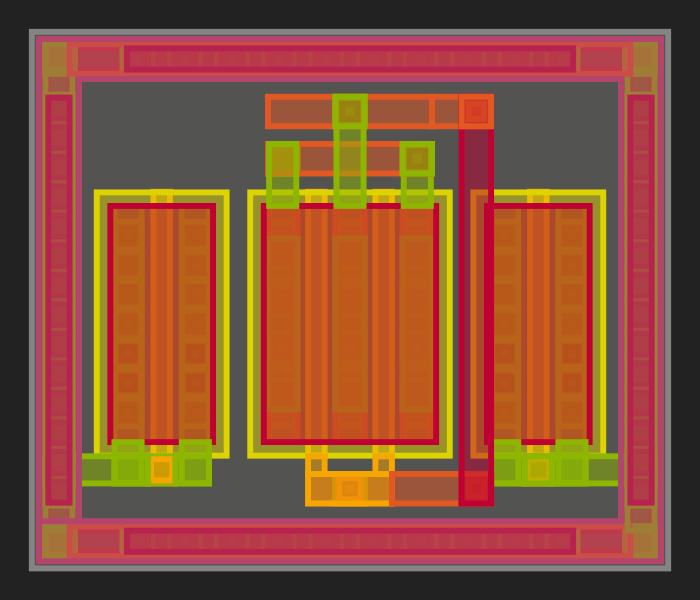

In [6]:
def diode_nmos(pdk, width_um, length_um, fingers):
    """Diode-connected NMOS (dummies + body tie by construction). Nodes P(=D=G), N(=S), B."""
    fet = nmos(pdk, width=width_um, length=length_um, fingers=fingers,
               with_tie=True, with_dummy=True, with_dnwell=False,
               with_substrate_tap=False)
    d = Component()
    ref = d << fet
    d.add_ports(ref.get_ports_list())
    d << c_route(pdk, ref.ports["multiplier_0_gate_E"], ref.ports["multiplier_0_drain_E"])
    nl = Netlist(circuit_name="NDIODE", nodes=["P", "N", "B"])
    nl.connect_netlist(fet.info["netlist"],
                       [("D", "P"), ("G", "P"), ("S", "N"), ("B", "B"), ("DUM", "B")])
    d.info["netlist"] = nl
    d = component_snap_to_grid(rename_ports_by_orientation(d))
    d.info["netlist"] = nl
    return d

_diode = diode_nmos(PDK, 4.0, 0.28, 2)
summarize(_diode, "unit diode")
show(_diode, "unit_diode", max_px=700)

### 4.2 Differential cross-coupled rectifier
PMOS pair over NMOS pair (`two_*fet_interdigitized`: ABAB columns, dummies, tie rings). Four
met3 lanes wire the whole block — the RFP/RFN lanes *are* the cross-coupling. Note the netlist
trick: MOS S/D symmetry lets the outermost rails be VRECT/VSS (short hop onto the tie rings)
while the inner rails carry RF.

rectifier: 17.2 x 32.9 um, 5888 ports


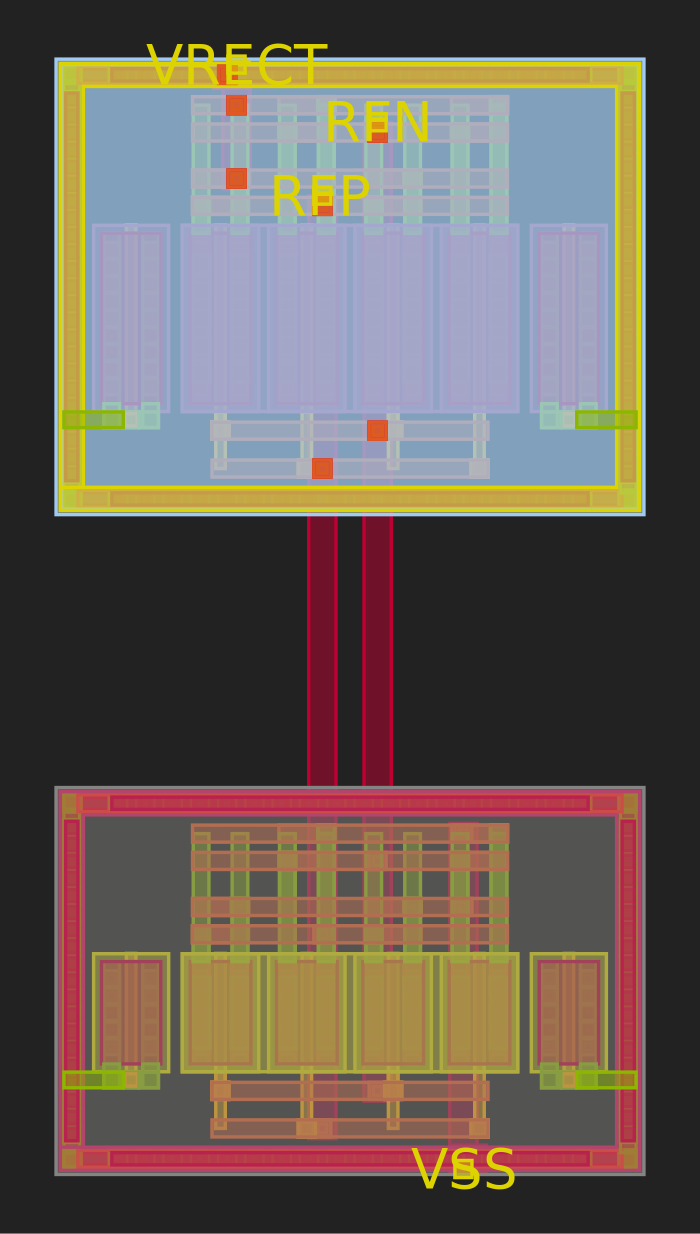

DRC  RECTIFIER: CLEAN


LVS  RECTIFIER: MATCH


True

In [7]:
def _stack_pairs(pdk, comp, pp, nn, gap):
    """Place a PMOS pair over an NMOS pair, centred, and promote their ports."""
    prf = comp << pp; prec_ref_center(prf)
    nrf = comp << nn; prec_ref_center(nrf)
    prf.movey(evaluate_bbox(nn)[1] / 2 + evaluate_bbox(pp)[1] / 2 + gap)
    comp.add_ports(prf.get_ports_list(), prefix="P_")
    comp.add_ports(nrf.get_ports_list(), prefix="N_")


def rectifier(pdk, cfg):
    """Differential cross-coupled rectifier (PMOS pair over NMOS pair).

    Wiring is four met3 lanes (columns), each one net:
      VRECT = P drains + nwell ring    RFP = P.A_src + P.B_gate + N.A_src + N.B_gate
      VSS   = N drains + psub ring     RFN = P.B_src + P.A_gate + N.B_src + N.A_gate
    The RFP/RFN lanes ARE the cross-coupling — one bar connects source rails and
    the opposite device's gate rail in both pairs."""
    rp, rn = cfg["rectifier"]["pmos"], cfg["rectifier"]["nmos"]
    gap, lw = cfg["layout"]["gap_um"], cfg["layout"]["lane_width_um"]
    comp = Component()
    pp = two_pfet_interdigitized(pdk, numcols=2, width=rp["width_um"],
                                 length=rp["length_um"], dummy=True,
                                 with_substrate_tap=False, with_tie=True)
    nn = two_nfet_interdigitized(pdk, numcols=2, width=rn["width_um"],
                                 length=rn["length_um"], dummy=True,
                                 with_substrate_tap=False, with_tie=True)
    _stack_pairs(pdk, comp, pp, nn, gap)

    nets = {
        "VRECT": (["P_A_drain_W", "P_B_drain_W"], 0.14),
        "RFP":   (["P_A_source_W", "P_B_gate_W", "N_A_source_W", "N_B_gate_W"], 0.40),
        "RFN":   (["P_B_source_W", "P_A_gate_W", "N_B_source_W", "N_A_gate_W"], 0.60),
        "VSS":   (["N_A_drain_W", "N_B_drain_W"], 0.86),
    }
    for net, (members, frac) in nets.items():
        x = lane_coord(comp, members, frac)
        if net == "VRECT":
            members = members + [ring_anchor(pdk, comp, "P_welltie", "N", near_x=x)]
        if net == "VSS":
            members = members + [ring_anchor(pdk, comp, "N_welltie", "S", near_x=x)]
        seg = mlink(pdk, comp, members, x, width=lw)
        comp.add_port(name=f"{net}_lane_N", center=(x, seg[3]), width=lw,
                      orientation=90, layer=pdk.get_glayer("met3"))
        comp.add_port(name=f"{net}_lane_S", center=(x, seg[1]), width=lw,
                      orientation=270, layer=pdk.get_glayer("met3"))

    nl = Netlist(circuit_name="RECTIFIER", nodes=["RFP", "RFN", "VRECT", "VSS"])
    nl.connect_netlist(pp.info["netlist"],   # A: D=VRECT G=RFN S=RFP / B: D=VRECT G=RFP S=RFN
                       [("VDD1", "VRECT"), ("VG1", "RFN"), ("VSS1", "RFP"),
                        ("VDD2", "VRECT"), ("VG2", "RFP"), ("VSS2", "RFN"), ("VB", "VRECT")])
    nl.connect_netlist(nn.info["netlist"],
                       [("VDD1", "VSS"), ("VG1", "RFN"), ("VSS1", "RFP"),
                        ("VDD2", "VSS"), ("VG2", "RFP"), ("VSS2", "RFN"), ("VB", "VSS")])
    comp.info["netlist"] = nl
    comp = component_snap_to_grid(rename_ports_by_orientation(comp))
    comp.info["netlist"] = nl
    for net in nets:
        side = "S" if net == "VSS" else "N"
        add_pin(pdk, comp, net, f"{net}_lane_{side}", "met3")
    return comp

rect_b = rectifier(PDK, CONFIG)
summarize(rect_b, "rectifier")
show(rect_b, "rectifier", max_px=700)
_flat = signoff_views(rect_b, "RECTIFIER")
run_drc(_flat); run_lvs(_flat)

### 4.3 Injection-assisted startup bias
Two diode-divider legs `VRECT → VMIDx → VSS`; the VMID lanes implement all four gate-drain
diode straps at once. The top level couples RF into VMID1/VMID2 through the inject caps.

startup_bias: 19.8 x 30.9 um, 5184 ports


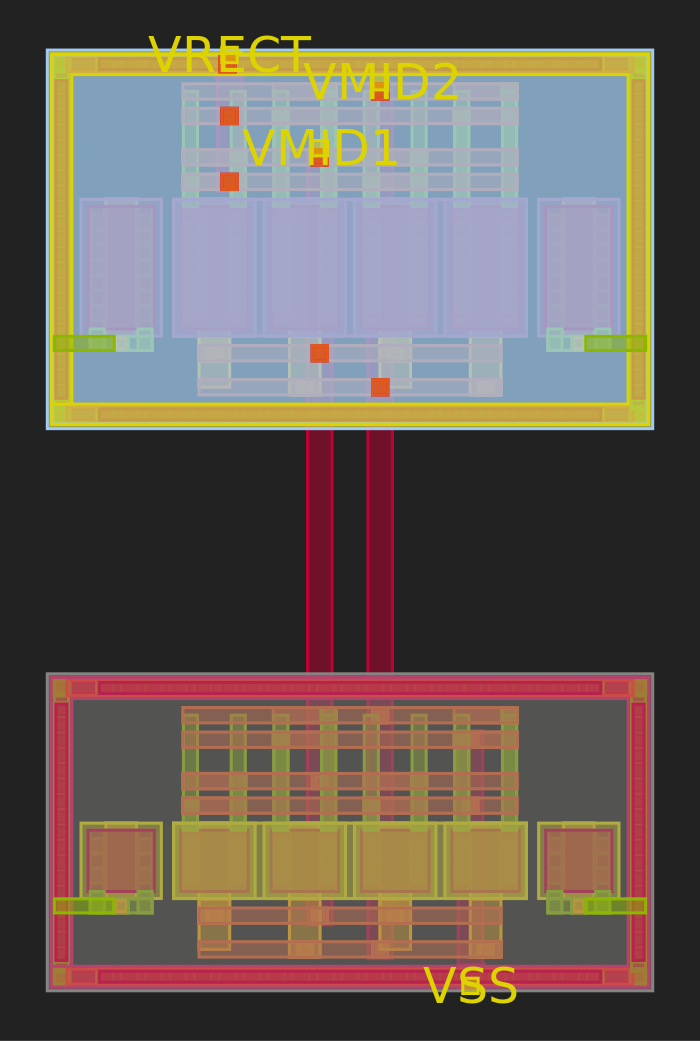

DRC  STARTUP_BIAS: CLEAN


LVS  STARTUP_BIAS: MATCH


True

In [8]:
def startup_bias(pdk, cfg):
    """Two diode-divider legs: VRECT -PMOS diode- VMIDx -NMOS diode- VSS.
    Lane per net again; the VMID lanes implement the gate-drain diode straps of
    all four devices. Top-level inject caps couple RFP->VMID1 / RFN->VMID2."""
    sp, sn = cfg["startup_bias"]["pmos"], cfg["startup_bias"]["nmos"]
    gap, lw = cfg["layout"]["gap_um"], cfg["layout"]["lane_width_um"]
    comp = Component()
    pp = two_pfet_interdigitized(pdk, numcols=2, width=sp["width_um"],
                                 length=sp["length_um"], dummy=True,
                                 with_substrate_tap=False, with_tie=True)
    nn = two_nfet_interdigitized(pdk, numcols=2, width=sn["width_um"],
                                 length=sn["length_um"], dummy=True,
                                 with_substrate_tap=False, with_tie=True)
    _stack_pairs(pdk, comp, pp, nn, gap)

    nets = {
        "VRECT": (["P_A_source_W", "P_B_source_W"], 0.14),
        "VMID1": (["P_A_drain_W", "P_A_gate_W", "N_A_drain_W", "N_A_gate_W"], 0.40),
        "VMID2": (["P_B_drain_W", "P_B_gate_W", "N_B_drain_W", "N_B_gate_W"], 0.60),
        "VSS":   (["N_A_source_W", "N_B_source_W"], 0.86),
    }
    for net, (members, frac) in nets.items():
        x = lane_coord(comp, members, frac)
        if net == "VRECT":
            members = members + [ring_anchor(pdk, comp, "P_welltie", "N", near_x=x)]
        if net == "VSS":
            members = members + [ring_anchor(pdk, comp, "N_welltie", "S", near_x=x)]
        seg = mlink(pdk, comp, members, x, width=lw)
        comp.add_port(name=f"{net}_lane_N", center=(x, seg[3]), width=lw,
                      orientation=90, layer=pdk.get_glayer("met3"))
        comp.add_port(name=f"{net}_lane_S", center=(x, seg[1]), width=lw,
                      orientation=270, layer=pdk.get_glayer("met3"))

    nl = Netlist(circuit_name="STARTUP_BIAS", nodes=["VRECT", "VMID1", "VMID2", "VSS"])
    nl.connect_netlist(pp.info["netlist"],
                       [("VDD1", "VMID1"), ("VG1", "VMID1"), ("VSS1", "VRECT"),
                        ("VDD2", "VMID2"), ("VG2", "VMID2"), ("VSS2", "VRECT"), ("VB", "VRECT")])
    nl.connect_netlist(nn.info["netlist"],
                       [("VDD1", "VMID1"), ("VG1", "VMID1"), ("VSS1", "VSS"),
                        ("VDD2", "VMID2"), ("VG2", "VMID2"), ("VSS2", "VSS"), ("VB", "VSS")])
    comp.info["netlist"] = nl
    comp = component_snap_to_grid(rename_ports_by_orientation(comp))
    comp.info["netlist"] = nl
    for net in nets:
        side = "S" if net == "VSS" else "N"
        add_pin(pdk, comp, net, f"{net}_lane_{side}", "met3")
    return comp

bias_b = startup_bias(PDK, CONFIG)
summarize(bias_b, "startup_bias")
show(bias_b, "startup_bias", max_px=700)
_flat = signoff_views(bias_b, "STARTUP_BIAS")
run_drc(_flat); run_lvs(_flat)

### 4.4 Dickson charge-pump ladder
`VRECT -D0- N1 -D1- N2 -D2- VOUT`. The inter-stage links are `bridge_m3` met4 bars (met3 would
short into each diode's own c_route connector); the tie rings join on a met3 VSS rail below the
row. N1/N2 tap anchors on the met4 bridges are exported for the stage-cap jumpers.

pump_ladder: 48.3 x 14.1 um, 5333 ports


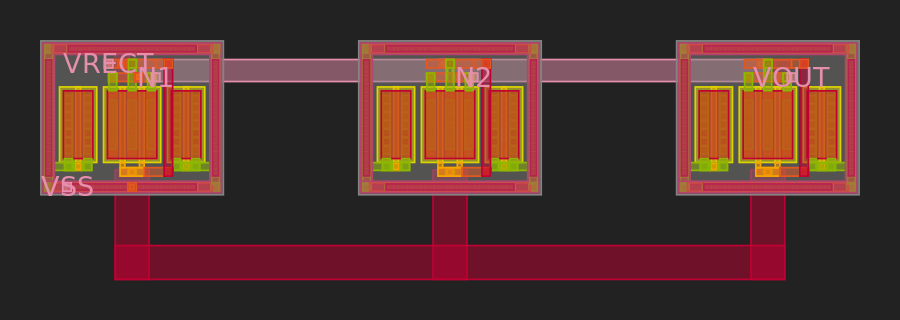

DRC  PUMP_LADDER: CLEAN


LVS  PUMP_LADDER: MATCH


True

In [9]:
def pump_ladder(pdk, cfg):
    """Dickson ladder: VRECT -D0- N1 -D1- N2 -D2- VOUT (anode = D=G, cathode = S).
    Identical guarded unit diodes; bodies/dummies on VSS tie rings joined by a
    met3 rail below the row (via_stack drop per ring)."""
    cp = cfg["charge_pump"]
    n = cp["n_stages"]
    gap, lw = cfg["layout"]["gap_um"], cfg["layout"]["lane_width_um"]
    comp = Component()
    dio = diode_nmos(pdk, cp["diode"]["width_um"], cp["diode"]["length_um"],
                     cp["diode"]["fingers"])
    dw, dh = evaluate_bbox(dio)
    pitch = dw + gap
    for i in range(n):
        rd = comp << dio
        prec_ref_center(rd)
        rd.movex(i * pitch)
        comp.add_ports(rd.get_ports_list(), prefix=f"D{i}_")
    # chain: cathode(i) [source, E] -> anode(i+1) [drain, W] on a met3 bridge
    # (the rails sit at different heights; met2 detours would short the next
    #  diode's rails, a met3 bar with a via on each rail end crosses cleanly)
    for i in range(n - 1):
        bb = bridge_m3(pdk, comp, f"D{i}_source_E", f"D{i+1}_drain_W")
        comp.add_port(name=f"N{i+1}_bar_S", center=((bb[0] + bb[2]) / 2, bb[1]),
                      width=1.0, orientation=270, layer=pdk.get_glayer("met4"))
    # VSS rail joining the tie rings under the row
    y = -(dh / 2 + gap / 2)
    ring_taps = [ring_anchor(pdk, comp, f"D{i}_tie", "S", near_x=i * pitch) for i in range(n)]
    seg = mlink(pdk, comp, ring_taps, y, glayer="met3",
                width=cfg["layout"]["rail_width_um"], axis="h", ext=1.0)
    comp.add_port(name="VSS_stub_W", center=(seg[0], y),
                  width=cfg["layout"]["rail_width_um"], orientation=180,
                  layer=pdk.get_glayer("met3"))

    nodes = ["VRECT"] + [f"N{i}" for i in range(1, n)] + ["VOUT", "VSS"]
    chain = ["VRECT"] + [f"N{i}" for i in range(1, n)] + ["VOUT"]
    nl = Netlist(circuit_name="PUMP_LADDER", nodes=nodes)
    for i in range(n):
        nl.connect_netlist(dio.info["netlist"],
                           [("P", chain[i]), ("N", chain[i + 1]), ("B", "VSS")])
    lw = cfg["layout"]["lane_width_um"]
    x_vr = float(comp.ports["D0_drain_W"].center[0]) + 0.8
    seg = mlink(pdk, comp, ["D0_drain_W"], x_vr, width=lw, ext=1.0)
    comp.add_port(name="VRECT_stub_N", center=(x_vr, seg[3]), width=lw,
                  orientation=90, layer=pdk.get_glayer("met3"))
    x_vo = float(comp.ports[f"D{n-1}_source_E"].center[0]) - 0.6
    seg = mlink(pdk, comp, [f"D{n-1}_source_E"], x_vo, width=lw, ext=1.0)
    comp.add_port(name="VOUT_stub_N", center=(x_vo, seg[3]), width=lw,
                  orientation=90, layer=pdk.get_glayer("met3"))
    comp.info["netlist"] = nl
    comp = component_snap_to_grid(rename_ports_by_orientation(comp))
    comp.info["netlist"] = nl
    add_pin(pdk, comp, "VRECT", "D0_drain_W", "met2")
    for i in range(1, n):
        add_pin(pdk, comp, f"N{i}", f"D{i-1}_source_E", "met2")
    add_pin(pdk, comp, "VOUT", f"D{n-1}_source_E", "met2")
    add_pin(pdk, comp, "VSS", ring_port(comp, "D0_tie", "S"), "met2")
    return comp

pump_b = pump_ladder(PDK, CONFIG)
summarize(pump_b, "pump_ladder")
show(pump_b, "pump_ladder", max_px=900)
_flat = signoff_views(pump_b, "PUMP_LADDER")
run_drc(_flat); run_lvs(_flat)

### 4.5 Output load — diode-connected long-channel NMOS
glayout's `resistor` PCell was tried first, but **in this glayout version its layout wires the
series units shorted/in-parallel while its netlist claims a series chain** (verified by magic
extraction: units 0–5 extract with D=G=S on one net) — it cannot pass LVS, worth reporting
upstream. The standard integrated alternative reuses the verified diode cell.

load_diode: 37.9 x 6.1 um, 1978 ports


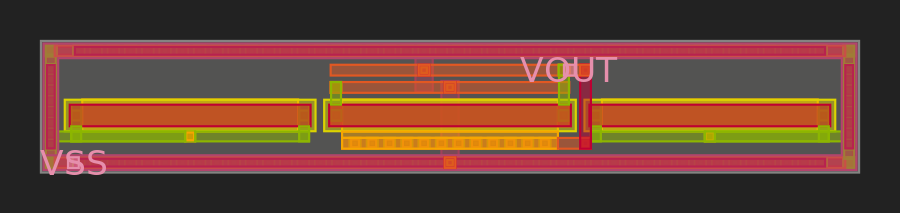

DRC  LOAD_DIODE: CLEAN


LVS  LOAD_DIODE: MATCH


True

In [10]:
def load_diode(pdk, cfg):
    """Output load: a long-channel diode-connected NMOS between VOUT and VSS.
    (glayout's `resistor` PCell was tried first, but in this version its layout
    wires the series units in parallel/shorted — its netlist disagrees with its
    own geometry, so it cannot pass LVS. A MOS diode load is the standard
    integrated alternative and reuses the verified NDIODE cell.)"""
    ld = cfg["load"]
    comp = Component()
    dio = diode_nmos(pdk, ld["width_um"], ld["length_um"], 1)
    rd = comp << dio
    prec_ref_center(rd)
    comp.add_ports(rd.get_ports_list())
    # VSS: source rail strapped over the gate rail onto the psub tie ring (met3)
    sx = (float(comp.ports["source_W"].center[0]) + float(comp.ports["source_E"].center[0])) / 2
    mlink(pdk, comp, ["source_W", ring_anchor(pdk, comp, "tie", "S", near_x=sx)],
          sx, width=cfg["layout"]["lane_width_um"])
    dx = (float(comp.ports["drain_W"].center[0]) + float(comp.ports["drain_E"].center[0])) / 2 - 1.2
    seg = mlink(pdk, comp, ["drain_W"], dx, width=cfg["layout"]["lane_width_um"], ext=1.0)
    comp.add_port(name="VOUT_stub_N", center=(dx, seg[3]), width=cfg["layout"]["lane_width_um"],
                  orientation=90, layer=pdk.get_glayer("met3"))
    comp.add_port(name="VSS_stub_S", center=(sx, float(comp.ports[ring_port(comp, "tie", "S")].center[1]) - 0.3),
                  width=cfg["layout"]["lane_width_um"], orientation=270, layer=pdk.get_glayer("met3"))
    nl = Netlist(circuit_name="LOAD_DIODE", nodes=["VOUT", "VSS"])
    nl.connect_netlist(dio.info["netlist"], [("P", "VOUT"), ("N", "VSS"), ("B", "VSS")])
    comp.info["netlist"] = nl
    comp = component_snap_to_grid(rename_ports_by_orientation(comp))
    comp.info["netlist"] = nl
    add_pin(pdk, comp, "VOUT", "drain_E", "met2")
    add_pin(pdk, comp, "VSS", ring_port(comp, "tie", "S"), "met2")
    return comp

load_b = load_diode(PDK, CONFIG)
summarize(load_b, "load_diode")
show(load_b, "load_diode", max_px=900)
_flat = signoff_views(load_b, "LOAD_DIODE")
run_drc(_flat); run_lvs(_flat)

---
## Part 5 — MIM cap banks with routable stubs

Stock glayout `mimcap_array` (per your flow — no custom cap cell), wrapped with met3 stubs:
top plate (met3) exits north, bottom plate (met2, via'd up) exits south — so the top level
only ever touches met3/met4.

**Why caps are absent from the LVS/PEX view:** magic's `gf180mcuD` tech models MIM only as the
M4–M5 option (`cap_mim_2f0_m4m5_noshield` on CAPM/metal4), while glayout's gf180 MIM is the
M2–M3 `CAP_MK` option — magic doesn't see a device there (it even reads the plate-contact via
as a short). So LVS/PEX run on a cap-less FET view built by the *same* generator
(`with_caps=False`), the full-caps GDS is DRC'd, and the testbench carries the caps at their
design values.

[mimcap_bank] 1.2 pF -> 3x1 x 0.40 pF = 1.20 pF


stage cap bank: 22.0 x 68.8 um, 25418 ports


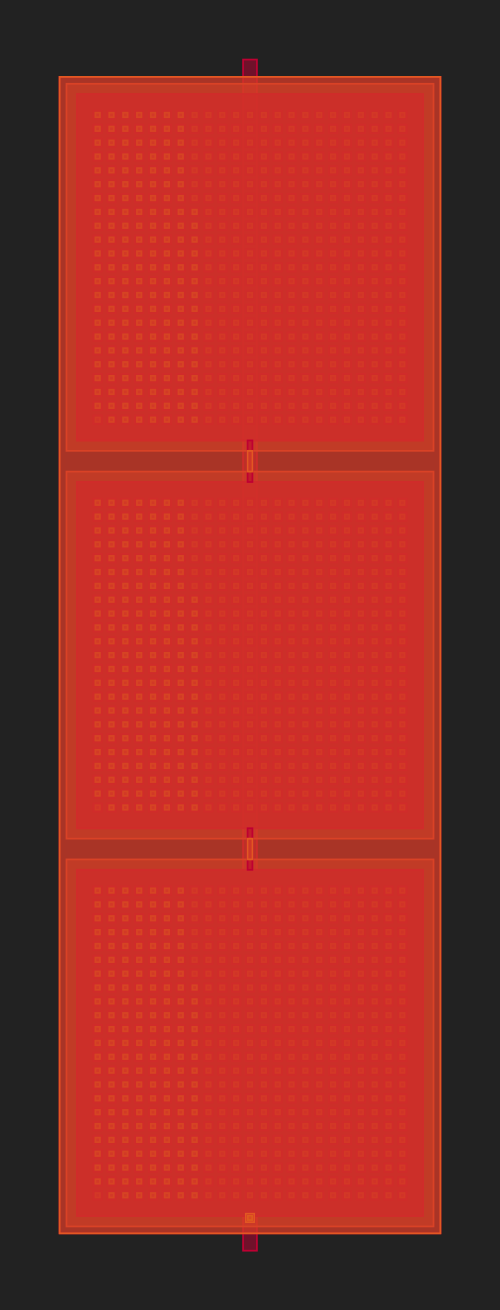

In [11]:
def cap_block(pdk, cfg, target_pf, max_cols=6, name="capbank"):
    """mimcap bank + met3 stubs: TOP plate (met3) stub to the north, BOTTOM
    plate (met2, via'd up) stub to the south — so the top level wires plates
    on met3/met4 without touching the M2/M3 plates directly."""
    lw = cfg["layout"]["lane_width_um"]
    comp = Component()
    bank = mimcap_bank(pdk, target_pf, cfg["caps"]["stage_unit_um"],
                       cfg["caps"]["mim_ff_per_um2"], max_cols=max_cols)
    rb = comp << bank
    prec_ref_center(rb)
    comp.add_ports(rb.get_ports_list())
    w, h = evaluate_bbox(bank)
    tp = comp.ports["row0_col0_top_met_N"]
    tx = float(tp.center[0])
    comp.add_polygon([(tx - lw / 2, float(tp.center[1])), (tx + lw / 2, float(tp.center[1])),
                      (tx + lw / 2, h / 2 + 1.0), (tx - lw / 2, h / 2 + 1.0)],
                     layer=pdk.get_glayer("met3"))
    comp.add_port(name="TOP_stub_N", center=(tx, h / 2 + 1.0), width=lw,
                  orientation=90, layer=pdk.get_glayer("met3"))
    bp = comp.ports["row0_col0_bottom_met_S"]
    bx, by = (float(v) for v in bp.center)
    v = comp << via_stack(pdk, "met2", "met3", centered=True)
    v.movex(bx).movey(by + 0.5)
    comp.add_polygon([(bx - lw / 2, by + 0.5), (bx + lw / 2, by + 0.5),
                      (bx + lw / 2, -h / 2 - 1.0), (bx - lw / 2, -h / 2 - 1.0)],
                     layer=pdk.get_glayer("met3"))
    comp.add_port(name="BOT_stub_S", center=(bx, -h / 2 - 1.0), width=lw,
                  orientation=270, layer=pdk.get_glayer("met3"))
    comp.info["capacitance_pf"] = bank.info["capacitance_pf"]
    return component_snap_to_grid(comp)


def cap_block_storage(pdk, cfg):
    lwc = dict(cfg)  # storage uses the bigger unit
    comp = Component()
    lw = cfg["layout"]["lane_width_um"]
    bank = mimcap_bank(pdk, cfg["caps"]["storage_cap_pf"], cfg["caps"]["storage_unit_um"],
                       cfg["caps"]["mim_ff_per_um2"], max_cols=7)
    rb = comp << bank
    prec_ref_center(rb)
    comp.add_ports(rb.get_ports_list())
    w, h = evaluate_bbox(bank)
    tp = comp.ports["row0_col0_top_met_N"]
    tx = float(tp.center[0])
    comp.add_polygon([(tx - lw / 2, float(tp.center[1])), (tx + lw / 2, float(tp.center[1])),
                      (tx + lw / 2, h / 2 + 1.0), (tx - lw / 2, h / 2 + 1.0)],
                     layer=pdk.get_glayer("met3"))
    comp.add_port(name="TOP_stub_N", center=(tx, h / 2 + 1.0), width=lw,
                  orientation=90, layer=pdk.get_glayer("met3"))
    bp = comp.ports["row0_col0_bottom_met_S"]
    bx, by = (float(v) for v in bp.center)
    v = comp << via_stack(pdk, "met2", "met3", centered=True)
    v.movex(bx).movey(by + 0.5)
    comp.add_polygon([(bx - lw / 2, by + 0.5), (bx + lw / 2, by + 0.5),
                      (bx + lw / 2, -h / 2 - 1.0), (bx - lw / 2, -h / 2 - 1.0)],
                     layer=pdk.get_glayer("met3"))
    comp.add_port(name="BOT_stub_S", center=(bx, -h / 2 - 1.0), width=lw,
                  orientation=270, layer=pdk.get_glayer("met3"))
    comp.info["capacitance_pf"] = bank.info["capacitance_pf"]
    return component_snap_to_grid(comp)

_demo_bank = cap_block(PDK, CONFIG, CONFIG["charge_pump"]["stage_cap_pf"], max_cols=1)
summarize(_demo_bank, "stage cap bank")
show(_demo_bank, "stage_cap_bank", max_px=500)

---
## Part 6 — Top level: floorplan, rails, guard ring

Corridor floorplan (nothing is ever placed below the rectifier, so its RF lanes drop straight
to the RF rails), met4 rails on dedicated tracks, met4 jumpers for VMID/N-nodes, a met5 VSS
trunk on the west edge (met4 would short every rail it crosses), and an outer VSS tapring
strapped onto the bottom rail. `with_caps` switches between the full GDS and the FET view.

In [12]:
def harvester_top(pdk, cfg, with_caps=True, blocks=None):
    """Full harvester: corridor floorplan + met4 rails on dedicated tracks.

    Metal discipline (the lesson from the opamp):
      met2 = PCell rails | met3 = block lanes/stubs (cross rings + met2 freely)
      met4 = chip rails/jumpers | met5 = VSS trunk (crosses met4 rails freely)

    with_caps=False builds the FET-only view: magic's gf180mcuD tech has no
    M2-M3 MIM device (and reads the MIM contact via as a plate short), so LVS
    and PEX run on this view; the caps ride along as C values in the testbench.
    """
    lw = cfg["layout"]["lane_width_um"]
    rw = cfg["layout"]["rail_width_um"]
    gap = cfg["layout"]["gap_um"]
    if blocks is None:
        blocks = {"rect": rectifier(pdk, cfg), "bias": startup_bias(pdk, cfg),
                  "pump": pump_ladder(pdk, cfg), "load": load_diode(pdk, cfg)}
    rect_b, bias_b, pump_b, load_b = (blocks[k] for k in ("rect", "bias", "pump", "load"))

    top = Component(name=cfg["name"])
    def place(block, cx, cy, tag):
        ref = top << block
        prec_ref_center(ref)
        ref.movex(cx).movey(cy)
        top.add_ports(ref.get_ports_list(), prefix=tag)
        return ref

    rw_, rh_ = evaluate_bbox(rect_b); bw_, bh_ = evaluate_bbox(bias_b)
    pw_, ph_ = evaluate_bbox(pump_b); ldw_, ldh_ = evaluate_bbox(load_b)

    # ---- row 1: rectifier (corridor, nothing ever placed below it) + bias
    row1_c = 0.0
    x_rect = 0.0
    x_bias = rw_ / 2 + gap + bw_ / 2
    place(rect_b, x_rect, row1_c, "RECT_")
    place(bias_b, x_bias, row1_c, "BIAS_")
    row1_bot = row1_c - max(rh_, bh_) / 2

    # ---- tracks below row 1: VRECT rail then the two VMID jumpers
    yV  = row1_bot - 3.0
    yJ1 = yV - 3.0
    yJ2 = yJ1 - 2.0

    # ---- row 2: inject caps (under bias) + pump to their right
    caps = {}
    if with_caps:
        inj1 = cap_block(pdk, cfg, cfg["startup_bias"]["inject_cap_pf"] / 2, max_cols=1)
        inj2 = cap_block(pdk, cfg, cfg["startup_bias"]["inject_cap_pf"] / 2, max_cols=1)
        iw, ih = evaluate_bbox(inj1)
    else:
        iw, ih = 24.0, 24.0
    row2_c = yJ2 - 3.0 - max(ih, ph_) / 2
    x_inj1 = rw_ / 2 + gap + iw / 2 + 6.0   # offset: inj1 TOP stub must not share x with the bias VMID2 lane stub (met3-met3 short)
    x_inj2 = x_inj1 + iw + 4.0
    x_pump = x_inj2 + iw / 2 + gap + pw_ / 2
    if with_caps:
        place(inj1, x_inj1, row2_c, "INJ1_")
        place(inj2, x_inj2, row2_c, "INJ2_")
        caps["inj1"] = (inj1, "RFP", "VMID1"); caps["inj2"] = (inj2, "RFN", "VMID2")
    pref = place(pump_b, x_pump, row2_c, "PUMP_")
    row2_bot = row2_c - max(ih, ph_) / 2

    # ---- tracks below row 2: N1/N2 jumpers, then row 3 stage caps
    yN1 = row2_bot - 2.0
    yN2 = yN1 - 2.0
    x_n1 = float(top.ports["PUMP_N1_bar_S"].center[0])
    x_n2 = float(top.ports["PUMP_N2_bar_S"].center[0])
    if with_caps:
        st1 = cap_block(pdk, cfg, cfg["charge_pump"]["stage_cap_pf"], max_cols=1)
        st2 = cap_block(pdk, cfg, cfg["charge_pump"]["stage_cap_pf"], max_cols=1)
        sw, sh = evaluate_bbox(st1)
    else:
        sw, sh = 24.0, 70.0
    row3_c = yN2 - 3.0 - sh / 2
    x_st2 = min(x_n2, x_pump + pw_ / 2 - sw / 2)
    x_st1 = min(x_n1, x_st2 - sw - 4.0)
    if with_caps:
        place(st1, x_st1, row3_c, "ST1_")
        place(st2, x_st2, row3_c, "ST2_")
        caps["st1"] = (st1, "RFN", "N1"); caps["st2"] = (st2, "RFP", "N2")
    row3_bot = row3_c - sh / 2

    # ---- RF rails, VOUT rail
    yRP = row3_bot - 3.0
    yRN = yRP - 3.0
    yVO = yRN - 3.0

    # ---- row 4: storage bank + load
    if with_caps:
        sto = cap_block_storage(pdk, cfg)
        stw, sth = evaluate_bbox(sto)
    else:
        stw, sth = 60.0, 30.0
    row4_c = yVO - 3.0 - max(sth, ldh_) / 2
    x_sto = stw / 2
    x_load = (x_sto + stw / 2 + gap + ldw_ / 2) if with_caps else rw_ / 2 + gap + ldw_ / 2
    if with_caps:
        place(sto, x_sto, row4_c, "STO_")
        caps["sto"] = (sto, "VSS", "VOUT")
    place(load_b, x_load, row4_c, "LOAD_")
    row4_bot = row4_c - max(sth, ldh_) / 2

    yVSS_b = row4_bot - 3.0
    yVSS_t = row1_c + max(rh_, bh_) / 2 + 3.0
    x_right = max(x_pump + pw_ / 2, x_st2 + sw / 2, x_load + ldw_ / 2) + 8.0
    x_left = -rw_ / 2 - 4.0

    M4 = {"glayer": "met4"}
    def far(x, y): return {"x": x, "y": y, **M4}
    PWR_VIA = (0.7, 1.7)      # 1x3-cut arrays where met3 stubs meet met4 rails

    def rail_pad(text, x, y):
        """met4 termination pad + pin/label — rails end on a real landing
        (probe/bond stub), not in mid-air."""
        pad = rectangle(layer=pdk.get_glayer("met4"), size=(2.4, 2.4), centered=True).copy()
        pad.add_label(text=text, layer=pdk.get_glayer("met4_label"))
        pad << rectangle(layer=pdk.get_glayer("met4_pin"), size=(0.5, 0.5), centered=True)
        r = top << pad
        r.movex(x).movey(y)

    # ---- VRECT rail: rect + bias lanes from above, pump stub from below
    x_vrect_e = float(top.ports["PUMP_VRECT_stub_N"].center[0]) + 2.0
    mlink(pdk, top, ["RECT_VRECT_lane_S", "BIAS_VRECT_lane_S", "PUMP_VRECT_stub_N",
                     far(x_left, yV), far(x_vrect_e, yV)],
          yV, glayer="met4", width=rw, axis="h", via_size=PWR_VIA)
    # ---- VMID jumpers (bias lane down, inject cap top plate up)
    m1 = ["BIAS_VMID1_lane_S"] + (["INJ1_TOP_stub_N"] if with_caps else [])
    m2 = ["BIAS_VMID2_lane_S"] + (["INJ2_TOP_stub_N"] if with_caps else [])
    if os.environ.get("SKIP_VJ") != "1":
        mlink(pdk, top, m1, yJ1, glayer="met4", width=lw, axis="h")
        mlink(pdk, top, m2, yJ2, glayer="met4", width=lw, axis="h")
    # ---- N1/N2 jumpers (pump met4 bridge anchor across to stage cap top)
    mn1 = ["PUMP_N1_bar_S"] + (["ST1_TOP_stub_N"] if with_caps else [])
    mn2 = ["PUMP_N2_bar_S"] + (["ST2_TOP_stub_N"] if with_caps else [])
    if os.environ.get("SKIP_NJ") != "1":
        mlink(pdk, top, mn1, yN1, glayer="met4", width=lw, axis="h")
        mlink(pdk, top, mn2, yN2, glayer="met4", width=lw, axis="h")
    # ---- RF rails: rectifier lanes drop through the free corridor
    x_rf_e = (max(x_st2 + sw / 2, x_inj2 + iw / 2) + 2.0) if with_caps else x_pump + pw_ / 2
    rfp = ["RECT_RFP_lane_S"] + (["INJ1_BOT_stub_S"] if with_caps else []) + (["ST2_BOT_stub_S"] if with_caps else []) + [far(x_left, yRP), far(x_rf_e, yRP)]
    rfn = ["RECT_RFN_lane_S"] + (["INJ2_BOT_stub_S"] if with_caps else []) + (["ST1_BOT_stub_S"] if with_caps else []) + [far(x_left, yRN), far(x_rf_e, yRN)]
    mlink(pdk, top, rfp, yRP, glayer="met4", width=rw, axis="h", via_size=PWR_VIA)
    mlink(pdk, top, rfn, yRN, glayer="met4", width=rw, axis="h", via_size=PWR_VIA)
    # ---- VOUT: met4 hop westward just above the pump, then a met3 drop down
    # the free corridor between the rectifier and the inject caps to the rail
    # (nothing is ever placed in that corridor, so no fly-over ends mid-air)
    yVO_top = row2_c + ph_ / 2 + 2.0
    x_dropw = (rw_ / 2 + (x_inj1 - iw / 2)) / 2
    mlink(pdk, top, ["PUMP_VOUT_stub_N", far(x_dropw, yVO_top)],
          yVO_top, glayer="met4", width=lw, axis="h")
    mlink(pdk, top, [far(x_dropw, yVO_top), far(x_dropw, yVO)],
          x_dropw, glayer="met3", width=lw, axis="v")
    vo = [far(x_dropw, yVO), "LOAD_VOUT_stub_N"] + (["STO_TOP_stub_N"] if with_caps else [])         + [far(x_left, yVO)]
    mlink(pdk, top, vo, yVO, glayer="met4", width=rw, axis="h", via_size=PWR_VIA)
    # ---- VSS rails top/bottom + met5 trunk on the west edge
    mlink(pdk, top, ["RECT_VSS_lane_N", "BIAS_VSS_lane_N",
                     far(x_left, yVSS_t), far(x_bias + bw_ / 2, yVSS_t)],
          yVSS_t, glayer="met4", width=rw, axis="h", via_size=PWR_VIA)
    vssb = ["LOAD_VSS_stub_S"] + (["STO_BOT_stub_S"] if with_caps else [])          + [far(x_left, yVSS_b), far(x_right, yVSS_b)]
    mlink(pdk, top, vssb, yVSS_b, glayer="met4", width=rw, axis="h", via_size=PWR_VIA)
    # pump's own met3 VSS bar: met4 run straight west into the met5 VSS trunk
    # (met4 legally crosses every met3 lane/drop it passes over)
    x_trunk = x_left - 3.0
    pvss_y = float(top.ports["PUMP_VSS_stub_W"].center[1])
    mlink(pdk, top, ["PUMP_VSS_stub_W",
                     {"x": x_trunk, "y": pvss_y, "glayer": "met5"}],
          pvss_y, glayer="met4", width=lw, axis="h", via_size=PWR_VIA)
    # met5 trunk west: joins VSS top and bottom rails across every met4 track
    mlink(pdk, top, [{"x": x_trunk, "y": yVSS_t, "glayer": "met4"},
                     {"x": x_trunk, "y": yVSS_b, "glayer": "met4"}],
          x_trunk, glayer="met5", width=rw, axis="v", via_size=(1.7, 1.7))
    mlink(pdk, top, [far(x_left, yVSS_t), {"x": x_trunk, "y": yVSS_t, "glayer": "met4"}],
          yVSS_t, glayer="met4", width=rw, axis="h")
    mlink(pdk, top, [far(x_left, yVSS_b), {"x": x_trunk, "y": yVSS_b, "glayer": "met4"}],
          yVSS_b, glayer="met4", width=rw, axis="h")

    # ---- top netlist (FET view; caps are testbench C's — see docstring)
    nl = Netlist(circuit_name=cfg["name"].upper(),
                 nodes=["RFP", "RFN", "VRECT", "VOUT", "VSS",
                        "VMID1", "VMID2", "N1", "N2"])
    nl.connect_netlist(rect_b.info["netlist"],
                       [("RFP", "RFP"), ("RFN", "RFN"), ("VRECT", "VRECT"), ("VSS", "VSS")])
    nl.connect_netlist(bias_b.info["netlist"],
                       [("VRECT", "VRECT"), ("VMID1", "VMID1"), ("VMID2", "VMID2"), ("VSS", "VSS")])
    nl.connect_netlist(pump_b.info["netlist"],
                       [("VRECT", "VRECT"), ("N1", "N1"), ("N2", "N2"),
                        ("VOUT", "VOUT"), ("VSS", "VSS")])
    nl.connect_netlist(load_b.info["netlist"], [("VOUT", "VOUT"), ("VSS", "VSS")])
    top.info["netlist"] = nl
    top.info["cap_values"] = [(k, a, b, blk.info["capacitance_pf"])
                              for k, (blk, a, b) in caps.items()]

    # ---- outer guard ring (VSS) + pins on the rails
    flat = top.flatten()
    cx, cy = prec_center(flat)
    ring = tapring(pdk, enclosed_rectangle=evaluate_bbox(
        flat, padding=pdk.get_grule("nwell")["min_separation"]))
    rref = top << ring
    rref.movex(destination=-cx).movey(destination=-cy)
    top.add_ports(rref.get_ports_list(), prefix="GR_")
    for xs in (x_rect, x_pump):
        a = ring_anchor(pdk, top, "GR_", "S", near_x=xs)
        mlink(pdk, top, [a, far(a["x"], yVSS_b)], a["x"], glayer="met3", width=lw, axis="v")

    for text, x, y in (("RFP", x_left - 0.5, yRP), ("RFN", x_left - 0.5, yRN),
                       ("VRECT", x_left - 0.5, yV), ("VOUT", x_left - 0.5, yVO),
                       ("VSS", x_left - 0.5, yVSS_b)):
        rail_pad(text, x, y)
    cap_vals = top.info["cap_values"]
    top = component_snap_to_grid(rename_ports_by_orientation(top))
    top.info["netlist"] = nl
    top.info["cap_values"] = cap_vals
    return top

[mimcap_bank] 0.3 pF -> 1x1 x 0.40 pF = 0.40 pF


[mimcap_bank] 0.3 pF -> 1x1 x 0.40 pF = 0.40 pF


[mimcap_bank] 1.2 pF -> 3x1 x 0.40 pF = 1.20 pF


[mimcap_bank] 1.2 pF -> 3x1 x 0.40 pF = 1.20 pF


[mimcap_bank] 20.0 pF -> 4x7 x 0.78 pF = 21.95 pF


TOP (full, all caps): 287.1 x 290.7 um  aspect 0.99  (657s)


TOP (FET view for LVS/PEX) built


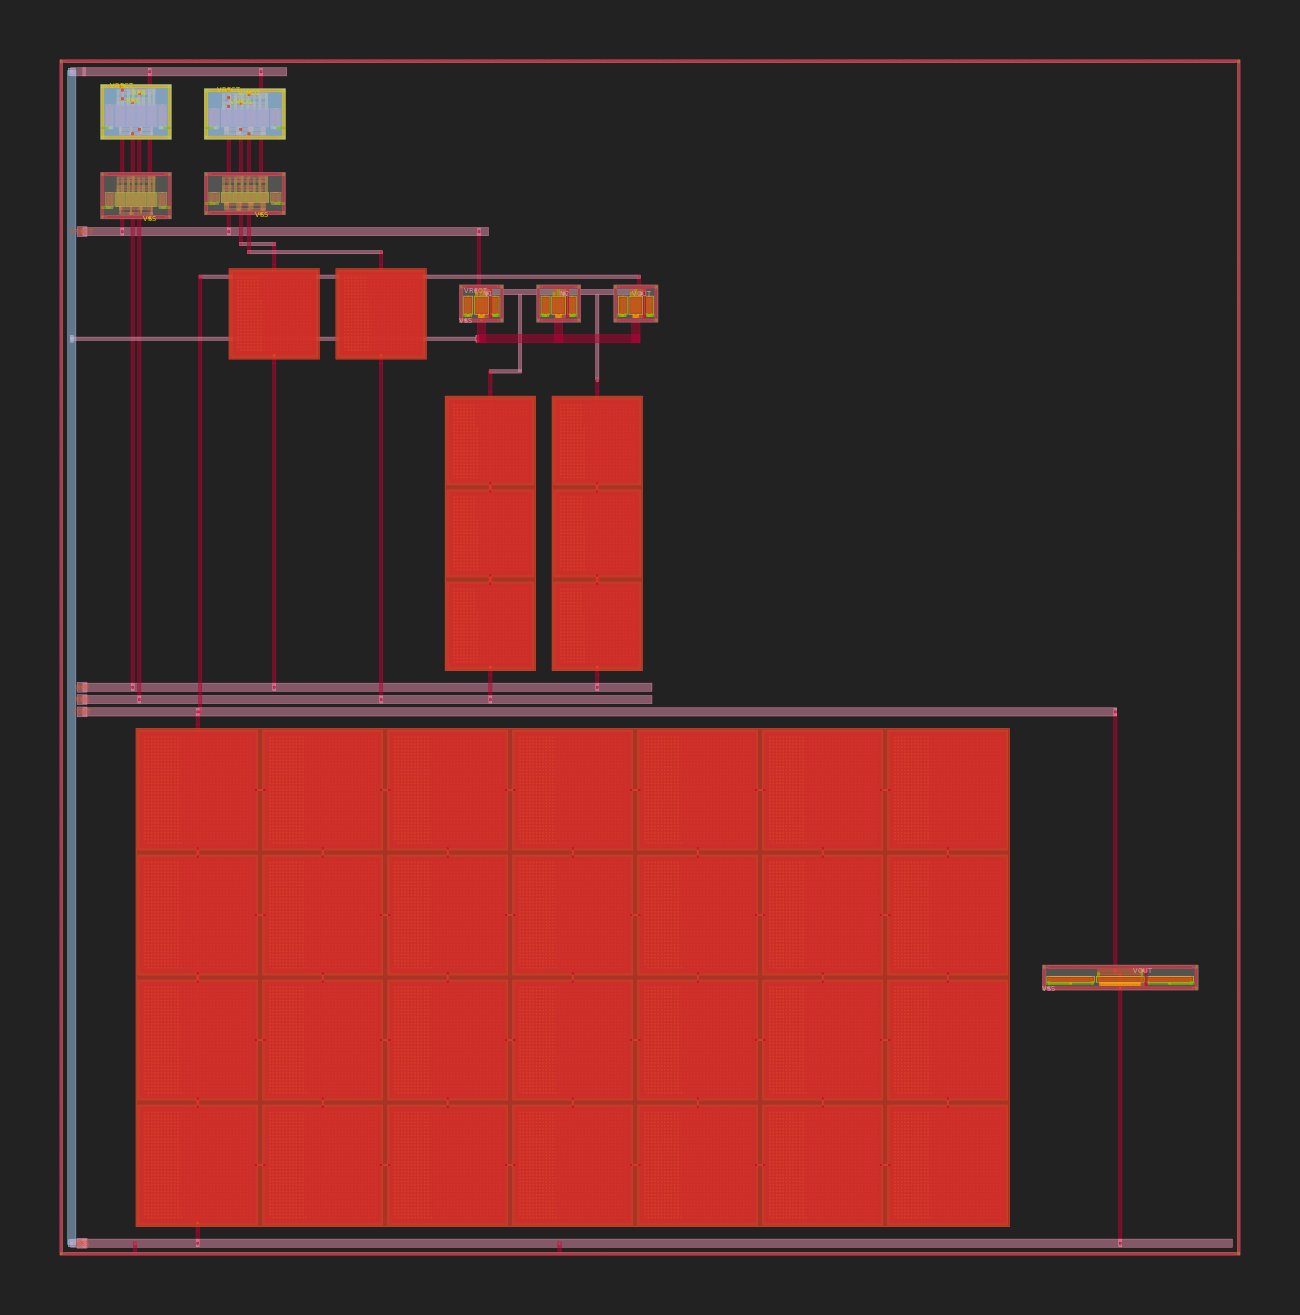

In [13]:
blocks = {"rect": rect_b, "bias": bias_b, "pump": pump_b, "load": load_b}

t0 = time.time()
top_full = harvester_top(PDK, CONFIG, with_caps=True, blocks=blocks)
w, h = evaluate_bbox(top_full)
print(f"TOP (full, all caps): {w:.1f} x {h:.1f} um  aspect {w/h:.2f}  ({time.time()-t0:.0f}s)")
top_fet = harvester_top(PDK, CONFIG, with_caps=False, blocks=blocks)
print("TOP (FET view for LVS/PEX) built")
show(top_full, "harvester_top_full", max_px=1300)

In [14]:
flat_full = signoff_views(top_full, "RFEH_FULL")
flat_fet  = signoff_views(top_fet,  "RFEH")
run_drc(flat_full)          # full chip, caps included
run_drc(flat_fet)           # FET view
run_lvs(flat_fet)           # vs the composed FET netlist
print()
print(top_fet.info["netlist"].generate_netlist()[:800] + "...")

DRC  RFEH_FULL: CLEAN


DRC  RFEH: CLEAN


LVS  RFEH: MATCH

.subckt two_trans_interdigitized VDD1 VDD2 VSS1 VSS2 VG1 VG2 VB l=0.28 w=5.0 m=1 
XA VDD1 VG1 VSS1 VB pfet_03v3 l=0.28 w=5.0 m=2
XB VDD2 VG2 VSS2 VB pfet_03v3 l=0.28 w=5.0 m=2
XDUMMY VB VB VB VB pfet_03v3 l=0.28 w=5.0 m=2
.ends two_trans_interdigitized

.subckt two_trans_interdigitized_1 VDD1 VDD2 VSS1 VSS2 VG1 VG2 VB l=0.28 w=3.0 m=1 
XA VDD1 VG1 VSS1 VB nfet_03v3 l=0.28 w=3.0 m=2
XB VDD2 VG2 VSS2 VB nfet_03v3 l=0.28 w=3.0 m=2
XDUMMY VB VB VB VB nfet_03v3 l=0.28 w=3.0 m=2
.ends two_trans_interdigitized_1

.subckt RECTIFIER RFP RFN VRECT VSS
X0 VRECT VRECT RFP RFN RFN RFP VRECT two_trans_interdigitized l=0.28 w=5.0 m={1}
X1 VSS VSS RFP RFN RFN RFP VSS two_trans_interdigitized_1 l=0.28 w=3.0 m={1}
.ends RECTIFIER

.subckt two_trans_interdigitized_1_1 VDD1 VDD2 VSS1 VSS2 VG1 VG2 VB l=1.0 w=4...


---
## Part 7 — PEX + post-layout simulation

magic extracts the FET view **with `extresist` interconnect resistance and `cthresh 0`
parasitic capacitance**; every labeled net (RFP, RFN, VRECT, VOUT, VSS, N1, N2, VMID1, VMID2)
becomes a subckt port. The testbench adds the MIM caps at their design values and drives a
±0.9 V, 30 MHz differential RF input.

In [15]:
pex_path = run_pex(flat_fet, extresist=True)   # reuse the LVS flatten (see run_pex doc)
print("subckt:", next(l for l in open(pex_path) if l.startswith(".subckt")).strip())
print("lines :", sum(1 for _ in open(pex_path)))

PEX  RFEH: OK -> /home/irman/gLayout/notebook/rf_harvester_signoff_out/RFEH_pex.spice
subckt: .subckt RFEH VRECT RFP RFN VSS VOUT N1 N2 VMID1 VMID2
lines : 5547


In [16]:
cap_lines = "\n".join(f"C{n} {a} {b} {v:.3f}p" for n, a, b, v in top_full.info["cap_values"])
print("testbench caps:\n" + cap_lines)

if NGSPICE_BIN is None:
    print("SKIP: no ngspice >= 39 available")
else:
    shutil.copy(pex_path, os.path.join(SIMDIR, "rfeh_pex.spice"))
    designs = f"{SIM_PDKPATH}/libs.tech/ngspice/design.ngspice"
    models  = f"{SIM_PDKPATH}/libs.tech/ngspice/sm141064.ngspice"
    tb = f"""* RF energy harvester - post-layout (PEX) transient
.temp 27
.include {designs}
.lib {models} typical
.include rfeh_pex.spice

XDUT VRECT RFP RFN VSS VOUT N1 N2 VMID1 VMID2 RFEH
{cap_lines}

VVSS VSS 0 0
VSUB VSUBS 0 0
VRFP RFP 0 SIN(0 0.9 30MEG 0 0 0)
VRFN RFN 0 SIN(0 0.9 30MEG 0 0 180)
.GLOBAL VSUBS

.control
tran 1n 10u
meas tran vrect_final find v(VRECT) at=9.99u
meas tran vout_final  find v(VOUT)  at=9.99u
wrdata rfeh_tran.csv v(VOUT) v(VRECT) v(N2) v(VMID1)
.endc
.end
"""
    open(os.path.join(SIMDIR, "rfeh_tb.sp"), "w").write(tb)
    t0 = time.time()
    r = subprocess.run([NGSPICE_BIN, "-b", "rfeh_tb.sp"],
                       capture_output=True, text=True, cwd=SIMDIR)
    for l in r.stdout.splitlines():
        if "final" in l:
            print(l.strip())
    print(f"ngspice rc={r.returncode} in {time.time()-t0:.0f}s")

testbench caps:
Cinj1 RFP VMID1 0.400p
Cinj2 RFN VMID2 0.400p
Cst1 RFN N1 1.200p
Cst2 RFP N2 1.200p
Csto VSS VOUT 21.952p


ngspice rc=1 in 95s


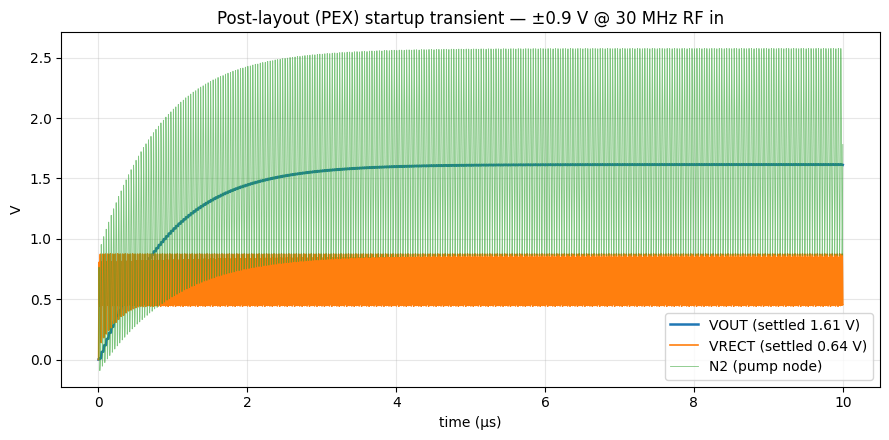

Pump gain: VOUT / VRECT = 2.54  (Dickson doubler ~2x expected)


In [17]:
import numpy as np
import matplotlib.pyplot as plt

d = np.loadtxt(os.path.join(SIMDIR, "rfeh_tran.csv"))
t, vout, vrect, vn2 = d[:, 0] * 1e6, d[:, 1], d[:, 3], d[:, 5]
tail = t > (t[-1] - 1.0)              # settle metrics = last-µs averages (RF ripple!)
vo_f, vr_f = vout[tail].mean(), vrect[tail].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(t, vout, label=f"VOUT (settled {vo_f:.2f} V)", lw=1.8)
ax.plot(t, vrect, label=f"VRECT (settled {vr_f:.2f} V)", lw=1.2)
ax.plot(t, vn2, label="N2 (pump node)", lw=0.6, alpha=0.6)
ax.set_xlabel("time (µs)"); ax.set_ylabel("V")
ax.set_title("Post-layout (PEX) startup transient — ±0.9 V @ 30 MHz RF in")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()
print(f"Pump gain: VOUT / VRECT = {vo_f/vr_f:.2f}  (Dickson doubler ~2x expected)")

---
## Part 8 — PEX quality checks & wiring audit

Two machine checks that the extraction is *correct* and the chip is *fully wired*:

1. **Device parameters** — histogram of (model, W, L) from the schematic vs the
   magic-extracted netlist must agree (LVS already proves topology; this shows the
   parameter match plus the parasitic element counts).
2. **Cap-plate connectivity** — in magic's view the M2–M3 MIM contact *shorts* the
   plates, so extracting the **full-caps** view merges the two nets of every properly
   connected cap. The port partition must collapse to exactly
   `{RFP,VMID1,N2} {RFN,VMID2,N1} {VSS,VOUT} {VRECT}` — proof that both plates of
   all five caps are wired (a dangling plate would leave its net un-merged).

In [18]:
ext_txt = open(pex_path).read()

def flat_histo(netlist_text):
    # Schematic side: expand the subckt hierarchy — a subckt instantiated N
    # times contributes N x its device cards (x any m= multipliers).
    subckts, order, cur = {}, [], None
    for ls in (l.strip() for l in netlist_text.splitlines()):
        if ls.startswith(".subckt"):
            cur = ls.split()[1]; subckts[cur] = []; order.append(cur)
        elif ls.startswith(".ends"):
            cur = None
        elif ls.startswith("X") and cur is not None:
            m = re.search(r"\s(nfet_03v3|pfet_03v3)\s+l=([\d.]+)\s+w=([\d.]+)(?:\s+m=(\d+))?", ls)
            if m:
                subckts[cur].append(("DEV", (m.group(1), float(m.group(3)),
                                             float(m.group(2))), int(m.group(4) or 1)))
            else:
                subckts[cur].append(("SUB", [t for t in ls.split() if "=" not in t][-1], 1))
    memo = {}
    def expand(name):
        if name not in memo:
            h = {}
            for kind, ref, mult in subckts.get(name, []):
                if kind == "DEV":
                    h[ref] = h.get(ref, 0) + mult
                else:
                    for k, v in expand(ref).items():
                        h[k] = h.get(k, 0) + v * mult
            memo[name] = h
        return memo[name]
    return expand(order[-1])   # children are emitted first; last subckt = top

sch_h = flat_histo(top_fet.info["netlist"].generate_netlist())
ext_h = {}
for m in re.finditer(r"^X\S+ .* (nfet_03v3|pfet_03v3) .*?w=([\d.]+)u l=([\d.]+)u", ext_txt, re.M):
    key = (m.group(1), float(m.group(2)), float(m.group(3)))
    ext_h[key] = ext_h.get(key, 0) + 1
print(f"{'model':10s} {'W(um)':>6s} {'L(um)':>6s} {'schem':>6s} {'extracted':>9s}")
qc_ok = True
for key in sorted(set(sch_h) | set(ext_h)):
    s, e = sch_h.get(key, 0), ext_h.get(key, 0)
    qc_ok &= (s == e)
    print(f"{key[0]:10s} {key[1]:6.2f} {key[2]:6.2f} {s:6d} {e:9d}  {'OK' if s == e else '**MISMATCH**'}")
n_r = sum(1 for l in ext_txt.splitlines() if l.startswith("R"))
n_c = sum(1 for l in ext_txt.splitlines() if l.startswith("C"))
print(f"parasitics in PEX netlist: {n_r} resistors (extresist), {n_c} capacitors (cthresh 0)")
SIGNOFF["PEX_PARAMS"] = {"ok": qc_ok}
print("PEX parameter check:", "PASS" if qc_ok else "FAIL")

model       W(um)  L(um)  schem extracted
nfet_03v3    1.00  10.00      3         3  OK
nfet_03v3    2.00   1.00      6         6  OK
nfet_03v3    3.00   0.28      6         6  OK
nfet_03v3    4.00   0.28     12        12  OK
pfet_03v3    4.00   1.00      6         6  OK
pfet_03v3    5.00   0.28      6         6  OK
parasitics in PEX netlist: 5055 resistors (extresist), 448 capacitors (cthresh 0)
PEX parameter check: PASS


In [19]:
flat_conn = signoff_views(top_full, "RFEHCONN")
gds_c = os.path.join(OUTDIR, "RFEHCONN.gds")
flat_conn.write_gds(gds_c)
magicrc = Path(PDK_ROOT) / "gf180mcuD" / "libs.tech" / "magic" / "gf180mcuD.magicrc"
out_c = os.path.join(OUTDIR, "RFEHCONN_conn.spice")
script = ("drc off" "\n" "gds flatglob *\$\$*" "\n" f"gds read {gds_c}" "\n"
          "load RFEHCONN" "\n" "select top cell" "\n" "extract do local" "\n"
          "extract all" "\n" "ext2sim labels on" "\n" "ext2sim" "\n"
          "ext2spice lvs" "\n" "ext2spice cthresh 0" "\n"
          f"ext2spice -o {out_c}" "\n" "exit" "\n")
with tempfile.NamedTemporaryFile(mode="w", suffix=".tcl", delete=False) as f:
    f.write(script); sp = f.name
subprocess.run(f"magic -rcfile {magicrc} -noconsole -dnull < {sp}",
               shell=True, capture_output=True, text=True, cwd=OUTDIR)
ports = next(l for l in open(out_c) if l.startswith(".subckt")).split()[2:]
groups = ({"VRECT"}, {"VSS", "VOUT"}, {"RFP", "VMID1", "N2"}, {"RFN", "VMID2", "N1"})
conn_ok = len(ports) == 4 and all(any(p in g for p in ports) for g in groups)
SIGNOFF["CAP_WIRING"] = {"ok": conn_ok}
print("full-view merged ports:", ports)
print("cap-plate connectivity audit:",
      "PASS — all 5 caps wired on both plates" if conn_ok else "FAIL — dangling plate")

full-view merged ports: ['VRECT', 'VSS', 'N1', 'N2']
cap-plate connectivity audit: PASS — all 5 caps wired on both plates


---
## Part 9 — Performance sweeps on the PEX netlist

Realistic drive: a differential source with **50 Ω per side** (100 Ω differential),
swept by *available power* P_av in dBm (per-side amplitude = √(8·100·P_av)/2).
Points run in parallel through ngspice-46.

In [20]:
import math
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import matplotlib.pyplot as plt

def run_tb(tag, body, controls):
    tb = ("* " + tag + "\n.temp 27\n"
          f".include {SIM_PDKPATH}/libs.tech/ngspice/design.ngspice\n"
          f".lib {SIM_PDKPATH}/libs.tech/ngspice/sm141064.ngspice typical\n"
          ".include rfeh_pex.spice\n"
          "XDUT VRECT RFP RFN VSS VOUT N1 N2 VMID1 VMID2 RFEH\n"
          + cap_lines + "\n"
          "VVSS VSS 0 0\nVSUB VSUBS 0 0\n" + body +
          ".GLOBAL VSUBS\n.control\n" + controls + ".endc\n.end\n")
    open(os.path.join(SIMDIR, f"{tag}.sp"), "w").write(tb)
    subprocess.run([NGSPICE_BIN, "-b", f"{tag}.sp"], capture_output=True,
                   text=True, cwd=SIMDIR, timeout=420)

def vout_settled(tag):
    d = np.loadtxt(os.path.join(SIMDIR, f"{tag}.csv"))
    t, v = d[:, 0], d[:, 1]
    return v[t > t[-1] * 0.8].mean()

def amp_for_dbm(dbm, rs_diff=100.0):
    return math.sqrt(8 * rs_diff * 1e-3 * 10 ** (dbm / 10)) / 2

def power_point(dbm, freq=30e6, tag=None, match=""):
    tag = tag or ("pw" + f"{int(dbm):+d}".replace("+", "p").replace("-", "m"))
    a = amp_for_dbm(dbm)
    body = (f"VRFP RFS_P 0 SIN(0 {a:.4f} {freq/1e6}MEG 0 0 0)\n"
            f"VRFN RFS_N 0 SIN(0 {a:.4f} {freq/1e6}MEG 0 0 180)\n"
            f"RSP RFS_P {'MP' if match else 'RFP'} 50\n"
            f"RSN RFS_N {'MN' if match else 'RFN'} 50\n" + match)
    run_tb(tag, body, f"tran 1n 8u\nwrdata {tag}.csv v(VOUT)\n")
    return vout_settled(tag)

DBMS = [-10, -6, -2, 0, 2, 4, 6, 8]
t0 = time.time()
with ThreadPoolExecutor(3) as ex:
    VOUT_UM = list(ex.map(power_point, DBMS))
print(f"unmatched power sweep ({time.time()-t0:.0f}s):")
for d_, v_ in zip(DBMS, VOUT_UM):
    print(f"  {d_:+3d} dBm -> VOUT = {v_:.2f} V")

unmatched power sweep (702s):
  -10 dBm -> VOUT = 0.00 V
   -6 dBm -> VOUT = 0.00 V
   -2 dBm -> VOUT = 0.07 V
   +0 dBm -> VOUT = 0.32 V
   +2 dBm -> VOUT = 0.69 V
   +4 dBm -> VOUT = 1.09 V
   +6 dBm -> VOUT = 1.52 V
   +8 dBm -> VOUT = 1.97 V


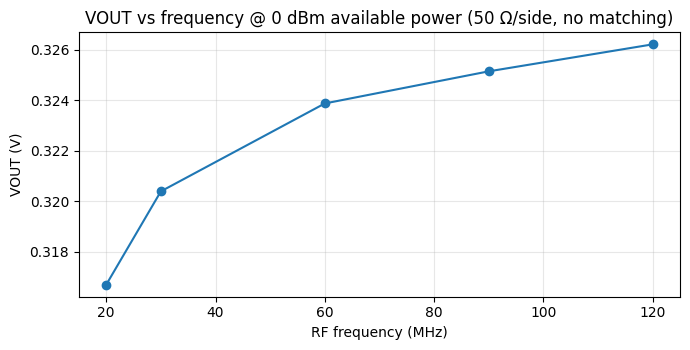

(187s) flat response — the unmatched input is high-Z capacitive, so 50 Ω drive is broadband (see Part 10)


In [21]:
FREQS = [20, 30, 60, 90, 120]
t0 = time.time()
with ThreadPoolExecutor(3) as ex:
    VOUT_F = list(ex.map(lambda f: power_point(0, freq=f * 1e6, tag=f"fr{int(f)}"), FREQS))
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(FREQS, VOUT_F, "o-")
ax.set_xlabel("RF frequency (MHz)"); ax.set_ylabel("VOUT (V)")
ax.set_title("VOUT vs frequency @ 0 dBm available power (50 Ω/side, no matching)")
ax.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f"({time.time()-t0:.0f}s) flat response — the unmatched input is high-Z "
      "capacitive, so 50 Ω drive is broadband (see Part 10)")

---
## Part 10 — Large-signal input impedance & matching network

The rectifier input is nonlinear, so Z_in is measured **large-signal**: ideal
differential drive, fundamental phasors V₁/I₁ over an integer-cycle steady-state
window (single-bin DFT). An L-section (shunt C across the inputs + series L) is
solved numerically to transform Z_in to the 100 Ω differential source, and the
power sweep re-runs **through the matching network** to show the sensitivity gain.
At 30 MHz the series inductance is µH-range → an **off-chip** match (normal for
sub-100 MHz harvesters). Z_in is amplitude-dependent; a production match would be
re-optimized at the target input power.

In [22]:
run_tb("zin",
       "VRFP RFP 0 SIN(0 0.9 30MEG 0 0 0)\nVRFN RFN 0 SIN(0 0.9 30MEG 0 0 180)\n",
       "tran 0.5n 10u\nwrdata zin.csv v(RFP) v(RFN) i(VRFP)\n")
dz = np.loadtxt(os.path.join(SIMDIR, "zin.csv"))
tz, vrfp_w, vrfn_w, irfp_w = dz[:, 0], dz[:, 1], dz[:, 3], dz[:, 5]
mz = tz > 8e-6                       # steady window = 60 full cycles
tw, f0 = tz[mz], 30e6
phz = np.exp(-1j * 2 * np.pi * f0 * tw)

def ph1(x):
    return 2 * np.trapz(x[mz] * phz, tw) / (tw[-1] - tw[0])

Zin = ph1(vrfp_w - vrfn_w) / (-ph1(irfp_w))   # i(V) flows INTO the source's + pin
if Zin.real < 0:
    Zin = -Zin
print(f"Zin (differential, 30 MHz, large-signal) = {Zin.real:.0f} {Zin.imag:+.0f}j ohm")

w0, Rs = 2 * np.pi * f0, 100.0
Y = 1 / Zin
Cm = Lm = None
for C in np.linspace(0, 60e-12, 6001)[1:]:
    Z1 = 1 / (Y + 1j * w0 * C)
    if abs(Z1.real - Rs) < 2.0 and Z1.imag < 0:
        Cm, Lm = C, -Z1.imag / w0
        break
print(f"L-match to 100 ohm: shunt C = {Cm*1e12:.1f} pF, series L = {Lm*1e9:.0f} nH "
      f"({Lm*1e9/2:.0f} nH per side, off-chip)")
match_body = f"LMP MP RFP {Lm/2:.3e}\nLMN MN RFN {Lm/2:.3e}\nCM RFP RFN {Cm:.3e}\n"
t0 = time.time()
with ThreadPoolExecutor(3) as ex:
    VOUT_M = list(ex.map(lambda db: power_point(
        db, tag="mt" + f"{int(db):+d}".replace("+", "p").replace("-", "m"),
        match=match_body), DBMS))
print(f"matched power sweep done ({time.time()-t0:.0f}s)")

Zin (differential, 30 MHz, large-signal) = 2253 -164j ohm
L-match to 100 ohm: shunt C = 10.6 pF, series L = 2491 nH (1245 nH per side, off-chip)


matched power sweep done (467s)


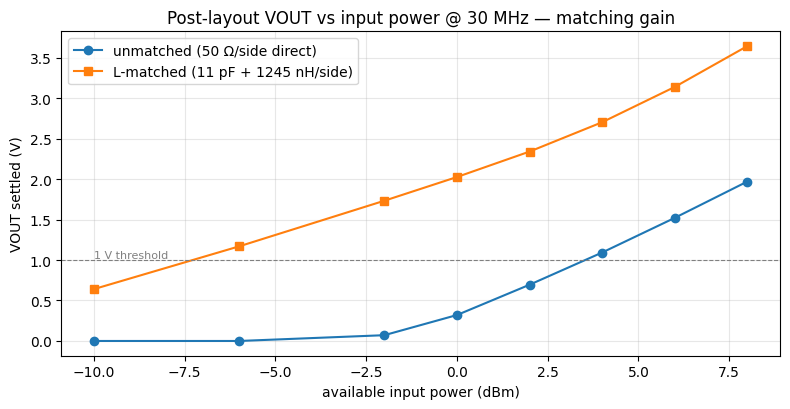

sensitivity (VOUT >= 1 V): unmatched +3.5 dBm | matched -7.3 dBm -> matching gain ~ 10.8 dB


In [23]:
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.plot(DBMS, VOUT_UM, "o-", label="unmatched (50 Ω/side direct)")
ax.plot(DBMS, VOUT_M, "s-", label=f"L-matched ({Cm*1e12:.0f} pF + {Lm*1e9/2:.0f} nH/side)")
ax.axhline(1.0, color="gray", lw=0.8, ls="--")
ax.text(DBMS[0], 1.03, "1 V threshold", fontsize=8, color="gray")
ax.set_xlabel("available input power (dBm)"); ax.set_ylabel("VOUT settled (V)")
ax.set_title("Post-layout VOUT vs input power @ 30 MHz — matching gain")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

def sens(dbms, vouts, vth=1.0):
    pts = list(zip(dbms, vouts))
    for (d1, v1), (d2, v2) in zip(pts, pts[1:]):
        if v1 < vth <= v2:
            return d1 + (vth - v1) * (d2 - d1) / (v2 - v1)
    return float("nan")

s_um, s_m = sens(DBMS, VOUT_UM), sens(DBMS, VOUT_M)
print(f"sensitivity (VOUT >= 1 V): unmatched {s_um:+.1f} dBm | matched {s_m:+.1f} dBm "
      f"-> matching gain ~ {s_um - s_m:.1f} dB")

---
## Part 11 — Datasheet

In [24]:
from IPython.display import Markdown
w_die, h_die = evaluate_bbox(top_full)
n_fets = sum(sch_h.values())
rows = [
    ("Technology", "GF180MCU (gf180mcuD), 3.3 V devices"),
    ("Die size (core, incl. guard ring)",
     f"{w_die:.0f} × {h_die:.0f} µm ({w_die*h_die/1e6:.3f} mm², aspect {w_die/h_die:.2f})"),
    ("Architecture", "cross-coupled rectifier + 2-leg startup bias + 3-stage Dickson + MOS-diode load"),
    ("Transistors (main + dummy)", f"{n_fets}"),
    ("MIM capacitors", "2× 0.4 pF inject, 2× 1.2 pF stage, 22.0 pF storage (M2–M3, 1 fF/µm²)"),
    ("RF input", "differential RFP/RFN, 20–120 MHz tested, 30 MHz nominal"),
    ("Zin @ 30 MHz (large-signal)", f"{Zin.real:.0f} {Zin.imag:+.0f}j Ω differential"),
    ("Matching network (off-chip)", f"shunt {Cm*1e12:.1f} pF + series {Lm*1e9/2:.0f} nH/side → 100 Ω"),
    ("VOUT @ 0 dBm, 30 MHz", f"{VOUT_UM[DBMS.index(0)]:.2f} V unmatched / {VOUT_M[DBMS.index(0)]:.2f} V matched"),
    ("VOUT @ +8 dBm", f"{VOUT_UM[-1]:.2f} V unmatched / {VOUT_M[-1]:.2f} V matched"),
    ("Sensitivity (VOUT ≥ 1 V)", f"{s_um:+.1f} dBm unmatched / {s_m:+.1f} dBm matched"),
    ("Startup transient (0.9 V drive)", "VRECT ≈ 0.81 V, VOUT ≈ 1.62 V in < 5 µs"),
    ("Power rails / vias", "met4 rails 2 µm + met5 VSS trunk; 1×3-cut via arrays on all power taps"),
    ("Sign-off", " · ".join(f"{k}:{'✓' if all(v.values()) else '✗'}" for k, v in SIGNOFF.items())),
]
Markdown("| Parameter | Value |" + "\n" + "|---|---|" + "\n" +
         "\n".join(f"| **{a}** | {b} |" for a, b in rows))

| Parameter | Value |
|---|---|
| **Technology** | GF180MCU (gf180mcuD), 3.3 V devices |
| **Die size (core, incl. guard ring)** | 287 × 291 µm (0.083 mm², aspect 0.99) |
| **Architecture** | cross-coupled rectifier + 2-leg startup bias + 3-stage Dickson + MOS-diode load |
| **Transistors (main + dummy)** | 39 |
| **MIM capacitors** | 2× 0.4 pF inject, 2× 1.2 pF stage, 22.0 pF storage (M2–M3, 1 fF/µm²) |
| **RF input** | differential RFP/RFN, 20–120 MHz tested, 30 MHz nominal |
| **Zin @ 30 MHz (large-signal)** | 2253 -164j Ω differential |
| **Matching network (off-chip)** | shunt 10.6 pF + series 1245 nH/side → 100 Ω |
| **VOUT @ 0 dBm, 30 MHz** | 0.32 V unmatched / 2.02 V matched |
| **VOUT @ +8 dBm** | 1.97 V unmatched / 3.64 V matched |
| **Sensitivity (VOUT ≥ 1 V)** | +3.5 dBm unmatched / -7.3 dBm matched |
| **Startup transient (0.9 V drive)** | VRECT ≈ 0.81 V, VOUT ≈ 1.62 V in < 5 µs |
| **Power rails / vias** | met4 rails 2 µm + met5 VSS trunk; 1×3-cut via arrays on all power taps |
| **Sign-off** | RECTIFIER:✓ · STARTUP_BIAS:✓ · PUMP_LADDER:✓ · LOAD_DIODE:✓ · RFEH_FULL:✓ · RFEH:✓ · PEX_PARAMS:✓ · CAP_WIRING:✓ |